In [51]:
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.cluster.hierarchy import linkage, leaves_list

os.chdir('..')

# Topology Sweep Analysis

Using simulation outputs generated by signal_topology_sweep.py, we investigate which signalling topologies give rise to distinct multicellular phenotypes at the colony level. <br>

Each cell contains the same fixed intracellular gene regulatory network (GRN), consisting of a three-way mutually repressive network. Across simulations, the signalling topology is varied to determine how different patterns of cell-cell communication influence collective cell-state organization and emergent multicellular phenotypes. <br>

<img src="../figures/3GeneSystem.png" width="500">

In [6]:
adata = ad.read_h5ad("Simulation_Results/3Gene/3Gene_unfiltered/3GeneResults.h5ad")

In [16]:
# Filter cells at final time step
adata_f = adata[np.isclose(adata.obs['time'],250)].copy()
adata_f

AnnData object with n_obs × n_vars = 341000 × 3
    obs: 'topology_id', 'time', 'param_set_id', 'colony_id', 'cell_id', 'k2_id', 'k1', 'k2', 'signal_s1', 'signal_s2', 'signal_s3'
    uns: 'k2_values', 'topology_params'

### Normalize and PCA

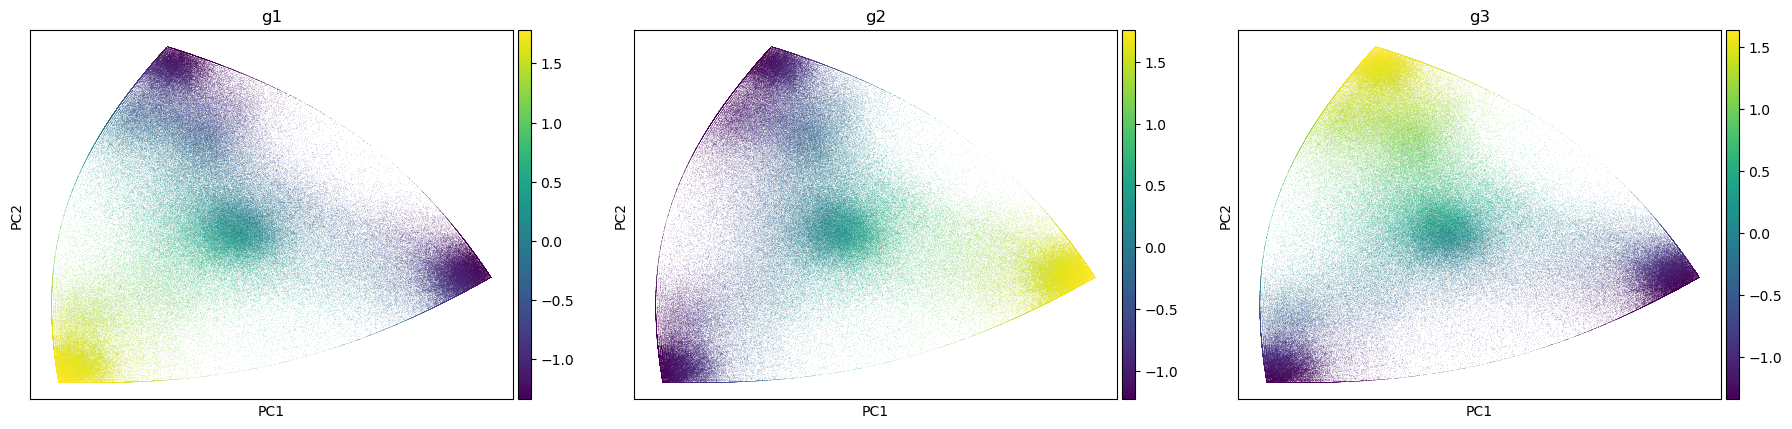

In [25]:
adata_f.X = adata_f.X.astype(np.float32)
sc.pp.scale(adata_f, zero_center=True, max_value=10)
sc.tl.pca(adata_f, n_comps=2, svd_solver="arpack")
sc.pl.pca(
    adata_f,
    color=['g1', 'g2', 'g3'],
)

### Clustering

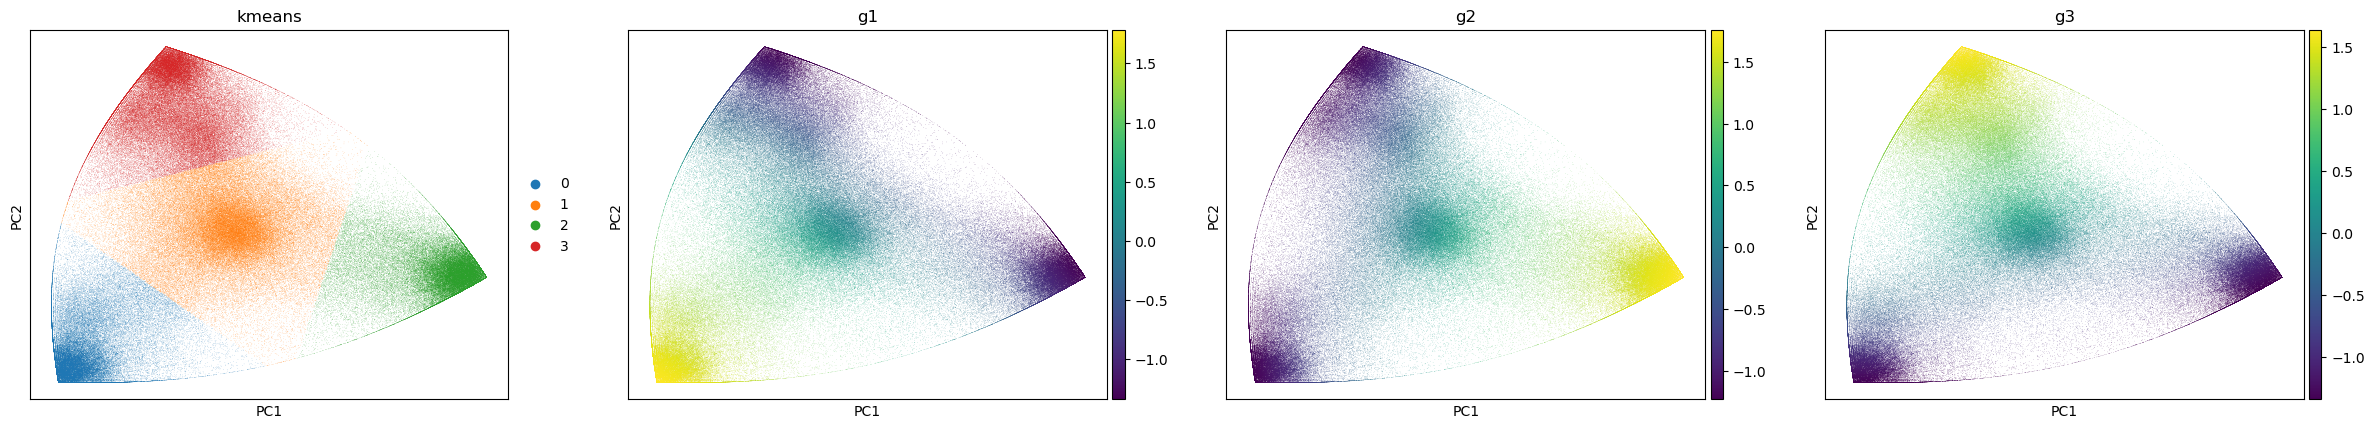

In [28]:
from sklearn.cluster import KMeans

# Clustering using K-means
X_embed = adata_f.obsm['X_pca']

kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto')
kmeans.fit(X_embed)

adata_f.obs['kmeans'] = kmeans.labels_.astype(str)

sc.pl.pca(
    adata_f,
    color=["kmeans", "g1", "g2", "g3"],
)

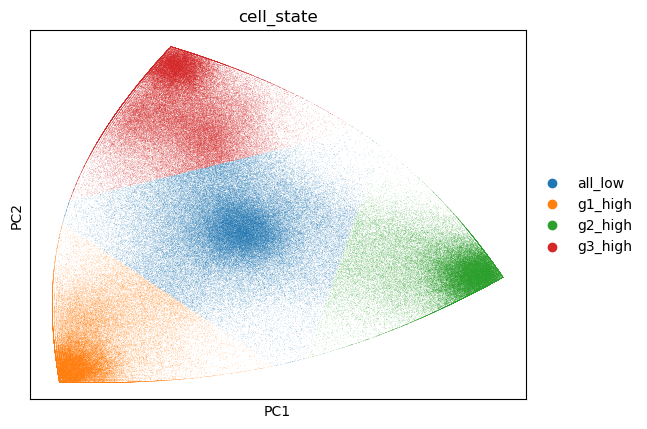

In [32]:
# give clusters more meaningful names
rename_map = {
    "0": "g1_high",
    "1": "all_low",
    "2": "g2_high",
    "3": "g3_high"
}

adata_f.obs["cell_state"] = (
    adata_f.obs["kmeans"].astype(str).map(rename_map)
    .fillna(adata_f.obs["kmeans"].astype(str))
)
adata_f.obs["cell_state"] = pd.Categorical(adata_f.obs["cell_state"])

sc.pl.pca(adata_f, color=["cell_state"])

## Plot Cell Type Distribution Per Colony For Each Signalling Topology

In [52]:
# Turn adata into df for plotting
df = adata_f_final.obs.copy()

In [53]:
# Function to classify a colony based on its unique cell states
def get_colony_state(cell_states):
  # Get sorted unique cell states present in this colony of 10 cells
  unique_states = sorted(cell_states.unique())

  # Handle cases (e.g., if you want to skip or include 'all_low')
  if len(unique_states) == 1:
    return f'homo {unique_states[0]}'
  elif len(unique_states) > 1:
    return f"mixed: {', '.join(unique_states)}"
  else:
    return 'undefined'

In [54]:
colony_states = (
    df.groupby(
        ['topology_id', 'colony_id'],
        observed=True
    )['cell_state']
    .apply(get_colony_state)
    .reset_index(name='colony_state')
)

freq_matrix = (
    colony_states.groupby(
        ['topology_id', 'colony_state'],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

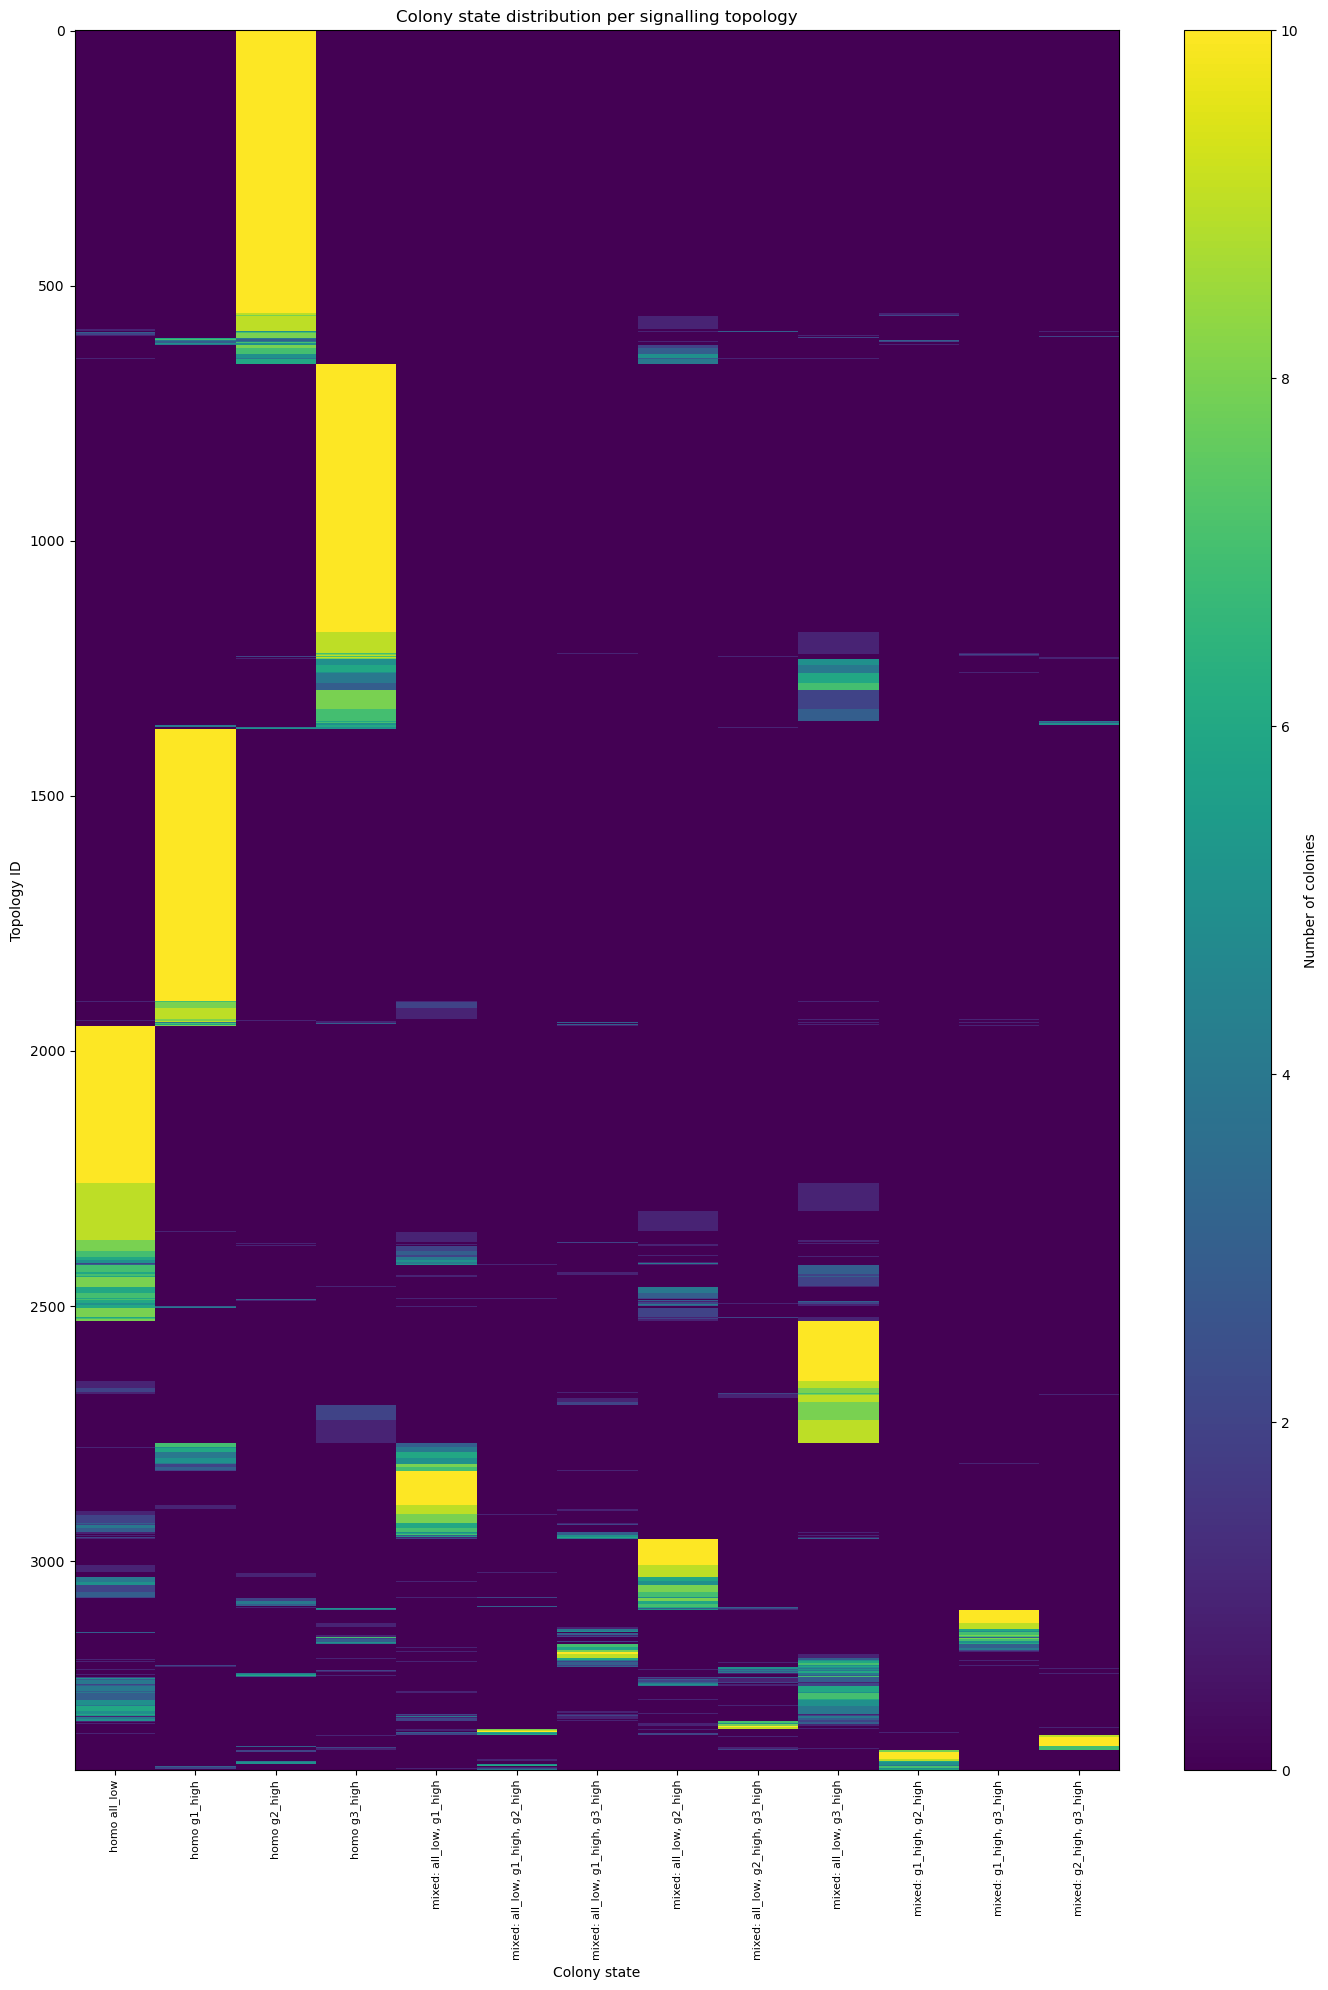

In [58]:
# Hierarchical clustering
Z = linkage(
    freq_matrix.values,
    method='ward',
    metric='euclidean'
)

# Get clustered topology ordering
order = leaves_list(Z)

# Reorder rows
ordered_matrix = freq_matrix.iloc[order]

# Plot
fig, ax = plt.subplots(figsize=(14, 20))

im = ax.imshow(
    ordered_matrix.values,
    aspect='auto',
    interpolation='nearest',
    vmin=0,
    vmax=10,
    cmap='viridis'
)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Number of colonies')

# X axis
ax.set_xlabel('Colony state')
ax.set_xticks(np.arange(len(ordered_matrix.columns)))
ax.set_xticklabels(
    ordered_matrix.columns,
    rotation=90,
    fontsize=8
)

# Y axis
ax.set_ylabel('Topology ID')

plt.title("Colony state distribution per signalling topology")
plt.tight_layout()
plt.show()